In [ ]:
pip install kagglehub pandas matplotlib seaborn

In [1]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

# Copio el archivo descargado a la carpeta dataset
dest = os.path.join(os.getcwd(), "dataset")
os.makedirs(dest, exist_ok=True)
for f in os.listdir(path):
    shutil.copy2(os.path.join(path, f), os.path.join(dest, f))

print("Path al dataset:", dest)

/media/july/100/Descargas/facu/automatizacion/mg-datos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path al dataset: /media/july/100/Descargas/facu/automatizacion/mg-datos/automatizacion/dataset


In [4]:
from pathlib import Path
import pandas as pd
diabetes = pd.read_csv("dataset/diabetes_prediction_dataset.csv")

In [5]:
diabetes.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [6]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [7]:
diabetes["smoking_history"].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [8]:
diabetes.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


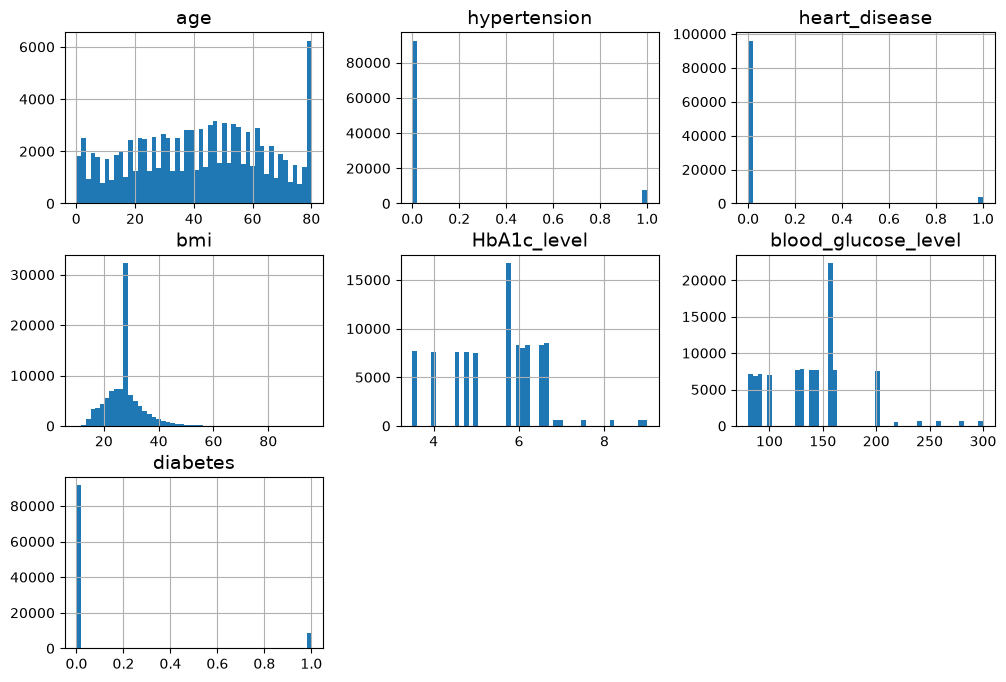

In [9]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

diabetes.hist(bins=50, figsize=(12, 8))

plt.show()

In [10]:
diabetes.duplicated().sum()

np.int64(3854)

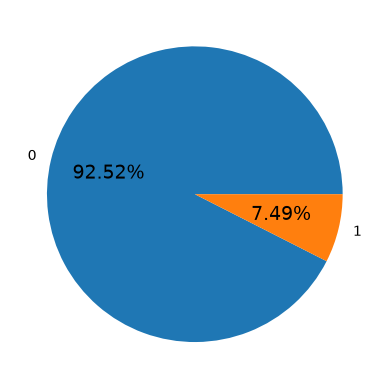

In [11]:
hypertension_counts = diabetes["hypertension"].value_counts()
plt.pie(x=hypertension_counts.values,labels=hypertension_counts.index,autopct='%.2f%%')
plt.show()

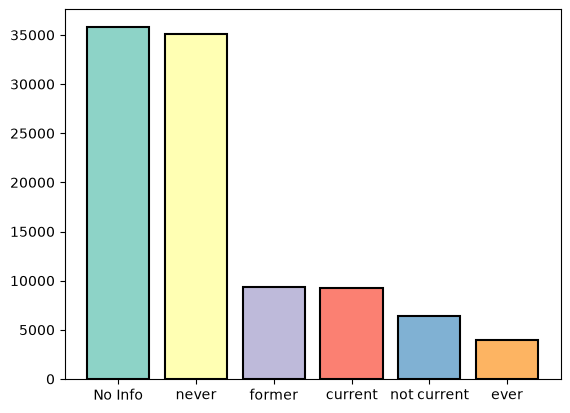

In [12]:
smoking_counts=diabetes["smoking_history"].value_counts()
smoking_labels = smoking_counts.index.to_list()
colors = plt.cm.Set3(range(len(smoking_labels)))
plt.bar(smoking_labels,smoking_counts.values,
    edgecolor='black', linewidth=1.5, color=colors)
plt.show()